In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

as_results = pd.read_parquet('binance/as_test_results')
symmetric_results = pd.read_parquet('binance/symmetric_test_results')

In [3]:
import backtest.run

table = pd.DataFrame([backtest.run.summarize(as_results, 'as'), backtest.run.summarize(symmetric_results, 'symmetric')])
print(table)

    strategy  terminal_wealth   spread_pnl    inv_pnl  bid_fills  ask_fills  \
0         as     -1488.713941  1777.075559 -3265.7895      17349      17333   
1  symmetric       396.969500  1931.445000 -1534.4755      19205      19271   

   mean_spread     q_std  mean_abs_q  max_abs_q  
0    10.049277  0.076355    0.061898       0.39  
1    10.040000  0.495277    0.587683       1.28  


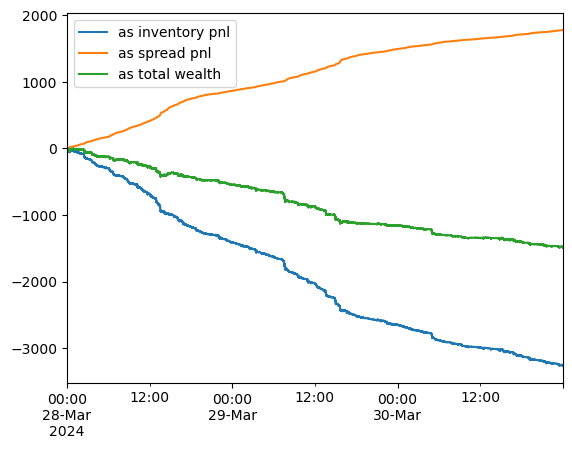

In [4]:
import matplotlib.pyplot as plt

inv_pnl = (as_results['q'].shift() * as_results['mid'].diff()).cumsum() # compute inventory riding market movement
spread_pnl = (as_results['wealth'] - as_results['wealth'].dropna().iloc[0]) - inv_pnl # cash flow

inv_pnl.plot(label = 'as inventory pnl')
spread_pnl.plot(label = 'as spread pnl')
as_results['wealth'].plot(label = 'as total wealth')
plt.legend()
plt.show()

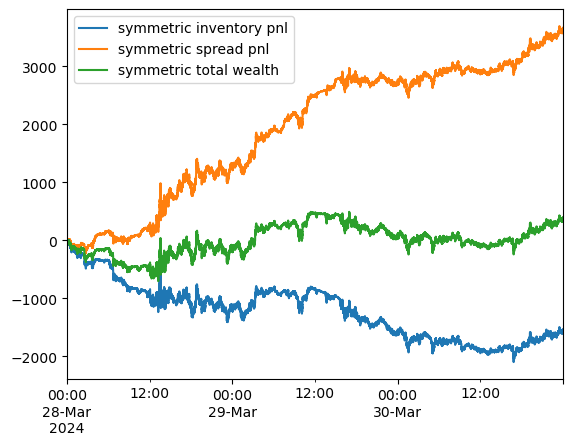

In [5]:
sym_inv_pnl = (symmetric_results['q'].shift() * symmetric_results['mid'].diff()).cumsum() # compute inventory riding market movement
sym_spread_pnl = (symmetric_results['wealth'] - symmetric_results['wealth'].dropna().iloc[0]) - inv_pnl # cash flow

sym_inv_pnl.plot(label = 'symmetric inventory pnl')
sym_spread_pnl.plot(label = 'symmetric spread pnl')
symmetric_results['wealth'].plot(label = 'symmetric total wealth')
plt.legend()
plt.show()